# EQTransformer — Quick Demo (uses included sample data)

**Before running:** Make sure the kernel says **EQTransformer (Python 3.9)** in the top-right corner.  
If not: go to **Kernel → Change Kernel → EQTransformer (Python 3.9)**

This notebook runs EQTransformer on the **100 real seismic waveforms** already included in the repo — no need to download anything.

In [1]:
# ── Step 1: Check everything is working ──────────────────────────────────
import sys, os
import numpy as np
import tensorflow as tf
import obspy

print('Python   :', sys.version.split('|')[0].strip())
print('TensorFlow:', tf.__version__)
print('NumPy    :', np.__version__)
print('ObsPy    :', obspy.__version__)
print()

import EQTransformer
print('EQTransformer loaded from:', EQTransformer.__file__)

Python   : 3.9.25 (main, Nov  3 2025, 22:44:01) [MSC v.1929 64 bit (AMD64)]
TensorFlow: 2.11.0
NumPy    : 1.26.4
ObsPy    : 1.4.2

EQTransformer loaded from: C:\Users\Or Shterenshus\Desktop\EQTransformer\EQTransformer\__init__.py


In [2]:
# ── Step 2: Point to the included sample data & pretrained model ──────────
import os

# These files ship with the repo — no download needed
SAMPLE_HDF5  = os.path.abspath('../ModelsAndSampleData/100samples.hdf5')
SAMPLE_CSV   = os.path.abspath('../ModelsAndSampleData/100samples.csv')
MODEL_PATH   = os.path.abspath('../ModelsAndSampleData/EqT_original_model.h5')
OUTPUT_DIR   = os.path.abspath('./demo_detections')

print('HDF5 file :', SAMPLE_HDF5,  '  exists:', os.path.exists(SAMPLE_HDF5))
print('CSV file  :', SAMPLE_CSV,   '  exists:', os.path.exists(SAMPLE_CSV))
print('Model file:', MODEL_PATH,   '  exists:', os.path.exists(MODEL_PATH))
print('Output dir:', OUTPUT_DIR)

HDF5 file : C:\Users\Or Shterenshus\Desktop\EQTransformer\ModelsAndSampleData\100samples.hdf5   exists: True
CSV file  : C:\Users\Or Shterenshus\Desktop\EQTransformer\ModelsAndSampleData\100samples.csv   exists: True
Model file: C:\Users\Or Shterenshus\Desktop\EQTransformer\ModelsAndSampleData\EqT_original_model.h5   exists: True
Output dir: C:\Users\Or Shterenshus\Desktop\EQTransformer\examples\demo_detections


In [3]:
# ── Step 3: Quick look at the sample data ────────────────────────────────
import h5py
import pandas as pd

df = pd.read_csv(SAMPLE_CSV)
print(f'Total waveforms in CSV: {len(df)}')
print(df.head())
print()

with h5py.File(SAMPLE_HDF5, 'r') as f:
    keys = list(f['data'].keys())
    print(f'Total waveforms in HDF5: {len(keys)}')
    print('First entry:', keys[0])
    waveform = f['data'][keys[0]][:]
    print('Shape of one waveform (samples x channels):', waveform.shape)

Total waveforms in CSV: 100
  network_code receiver_code receiver_type  receiver_latitude  \
0           TA          109C            BH            32.8889   
1           TA          109C            BH            32.8889   
2           TA          109C            BH            32.8889   
3           TA          109C            BH            32.8889   
4           TA          109C            BH            32.8889   

   receiver_longitude  receiver_elevation_m  p_arrival_sample p_status  \
0           -117.1051                 150.0             700.0   manual   
1           -117.1051                 150.0             600.0   manual   
2           -117.1051                 150.0             500.0   manual   
3           -117.1051                 150.0             900.0   manual   
4           -117.1051                 150.0             700.0   manual   

   p_weight  p_travel_sec  ...  source_magnitude_author  \
0       0.5     17.080000  ...                      NaN   
1       0.5     16

In [4]:
# ── Step 4: Visualise one raw waveform ───────────────────────────────────
import matplotlib.pyplot as plt
import h5py

with h5py.File(SAMPLE_HDF5, 'r') as f:
    keys  = list(f['data'].keys())
    wave  = f['data'][keys[0]][:]
    title = keys[0]

channels = ['E', 'N', 'Z']
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
fig.suptitle(f'Raw seismic waveform: {title}', fontsize=13)
for i, ax in enumerate(axes):
    ax.plot(wave[:, i], lw=0.7)
    ax.set_ylabel(channels[i])
    ax.set_xlim(0, wave.shape[0])
axes[-1].set_xlabel('Sample index (6000 samples = 60 seconds at 100 Hz)')
plt.tight_layout()
plt.show()

In [5]:
# ── Step 5: Run EQTransformer detection on all 100 samples ───────────────
# This is the main event — the model will detect earthquakes & pick P/S waves
from EQTransformer.core.predictor import predictor

predictor(
    input_dir          = os.path.dirname(SAMPLE_HDF5),   # folder containing the hdf5
    input_model        = MODEL_PATH,
    output_dir         = OUTPUT_DIR,
    estimate_uncertainty = False,
    output_probabilities = False,
    number_of_sampling   = 5,
    loss_weights         = [0.02, 0.40, 0.58],
    detection_threshold  = 0.3,
    P_threshold          = 0.3,
    S_threshold          = 0.3,
    number_of_plots      = 3,       # save plots for the first 3 detections
    plot_mode            = 'time',
    batch_size           = 100,
    number_of_cpus       = 2,
    keepPS               = False,
    spLimit              = 60
)

Running EqTransformer  0.1.61
 *** Loading the model ...


*** Loading is complete!
*** C:\Users\Or Shterenshus\Desktop\EQTransformer\examples\demo_detections already exists! Overwriting automatically.
######### There are files for 4 stations in C:\Users\Or Shterenshus\Desktop\EQTransformer\ModelsAndSampleData directory. #########
========= Started working on 100samples, 1 out of 4 ...
  0%|                                                                         | 0/1 [00:00<?, ?it/s]

 *** Finished the prediction in: 0 hours and 0 minutes and 12.17 seconds.
 *** Detected: 99 events.
 *** Wrote the results into --> " C:\Users\Or Shterenshus\Desktop\EQTransformer\examples\demo_detections\100samples_outputs "
*** Skipping "EqT_model_conservative" — no matching .hdf5/.csv data pair found.
*** Skipping "EqT_original_model" — no matching .hdf5/.csv data pair found.
*** Skipping "test" — no matching .hdf5/.csv data pair found.
100%|█████████████████████████████████████████████████████████████████| 1/1 [00:12<00:00, 12.19s/it]


In [6]:
# ── Step 6: Show the results ─────────────────────────────────────────────
import glob

csv_files = glob.glob(os.path.join(OUTPUT_DIR, '**', '*prediction_results.csv'), recursive=True)
if csv_files:
    results = pd.read_csv(csv_files[0])
    print(f'Detected {len(results)} events')
    print(results.head(10))
else:
    print('No results file found yet — check the output directory:', OUTPUT_DIR)

Detected 99 events
                   file_name network station instrument_type  station_lat  \
0  109C.TA_20060723155859_EV      TA    109C              EV      32.8889   
1  109C.TA_20061103155652_EV      TA    109C              EV      32.8889   
2  109C.TA_20061103161223_EV      TA    109C              EV      32.8889   
3  109C.TA_20061114133221_EV      TA    109C              EV      32.8889   
4  109C.TA_20061127104640_EV      TA    109C              EV      32.8889   
5  109C.TA_20061129121745_EV      TA    109C              EV      32.8889   
6  109C.TA_20061129211102_EV      TA    109C              EV      32.8889   
7  109C.TA_20061129211301_EV      TA    109C              EV      32.8889   
8  109C.TA_20061129221547_EV      TA    109C              EV      32.8889   
9  109C.TA_20070109140205_EV      TA    109C              EV      32.8889   

   station_lon  station_elv            event_start_time  \
0    -117.1051        150.0  2006-07-23 15:59:07.990000   
1    -117.1051 

Found 3 plot(s). Showing the first one:


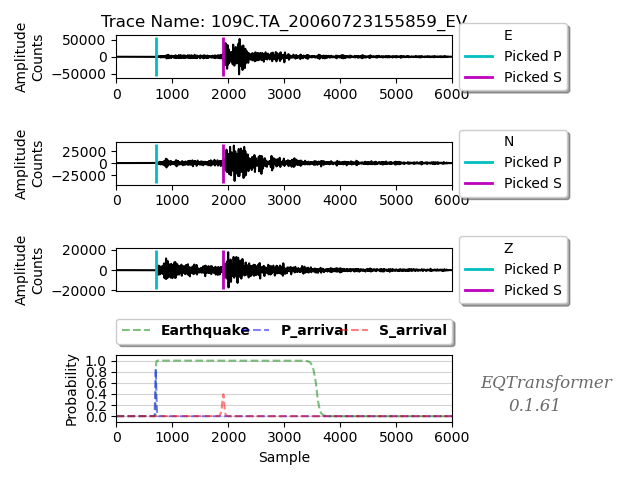

In [7]:
# ── Step 7: Show a detection plot saved by EQTransformer ─────────────────
from IPython.display import Image
import glob

plots = glob.glob(os.path.join(OUTPUT_DIR, '**', '*.png'), recursive=True)
if plots:
    print(f'Found {len(plots)} plot(s). Showing the first one:')
    display(Image(filename=plots[0], width=900))
else:
    print('No plots found — try increasing number_of_plots in Step 5')

In [8]:
# === Inspect the EQTransformer model ===
from tensorflow.keras.models import load_model
from EQTransformer.core.EqT_utils import SeqSelfAttention, FeedForward, LayerNormalization, f1

model = load_model(
    MODEL_PATH,
    custom_objects={
        'SeqSelfAttention': SeqSelfAttention,
        'FeedForward': FeedForward,
        'LayerNormalization': LayerNormalization,
        'f1': f1
    }
)

# Print every layer: name, type, output shape, parameter count
model.summary()

# Total parameters
total = model.count_params()
print(f'\nTotal parameters: {total:,}')
print(f'Model size (approx): {total * 4 / 1024 / 1024:.1f} MB')

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, 6000, 3)]    0           []                               
                                                                                                  
 conv1d_1 (Conv1D)              (None, 6000, 8)      272         ['input[0][0]']                  
                                                                                                  
 max_pooling1d_1 (MaxPooling1D)  (None, 3000, 8)     0           ['conv1d_1[0][0]']               
                                                                                                  
 conv1d_2 (Conv1D)              (None, 3000, 16)     1168        ['max_pooling1d_1[0][0]']        
                                                                                            